# 🚗 Insurance Cross Selling: EDA & LGBM

## 📖 Proje Amacı

Kaggle **S4E7 Insurance Cross Selling** yarışmasının temel amacı, bir sigorta şirketinin mevcut sağlık sigortası müşterilerinin, kendilerine sunulacak olan **Araç Sigortası** teklifine ilgi duyup duymayacağını tahmin etmektir. Şirketler için çapraz satış stratejileri, pazarlama maliyetlerini düşürmek ve müşteri sadakatini artırmak adına hayati bir önem taşır.

Bu çalışmada, müşterilerin demografik bilgileri (yaş, cinsiyet, ikamet bölgesi), araç geçmişleri (araç yaşı, geçmiş hasar durumu) ve şirketle olan ilişkileri (ilişki süresi, halihazırdaki sigorta durumu) analiz edilerek, potansiyel müşteriler hedeflenmiştir. 11.5 milyon satırlık bu devasa veri setinde, doğru müşteriyi bulmak sadece bir tahmin değil, aynı zamanda büyük veri işleme kapasitesine dayalı bir mühendislik problemidir.

Bu problem bir **İkili Sınıflandırma (Binary Classification)** görevi olarak ele alınmıştır. Hedef değişkenimiz olan `Response` (Teklife İlgi) durumunu en yüksek **ROC-AUC** skoruyla tahmin etmek amacıyla şu yol haritası izlenmiştir:

1. **Büyük Veri Analizi (EDA):** Milyonlarca satır içindeki gizli desenlerin keşfi; hangi yaş gruplarının ve hangi araç geçmişine sahip kişilerin teklife daha sıcak baktığının analizi.
2. **Bellek Optimizasyonu & Ön İşleme:** Bellek kullanımını düşürmek için veri tiplerinin küçültülmesi (downcasting) ve kategorik değişkenlerin modele uygun hale getirilmesi.
3. **Özellik Mühendisliği (Feature Engineering):** Araç yaşı ve geçmiş hasar durumu gibi kritik bilgilerin etkileşimlerini kullanarak modelin ayırt edici gücünün artırılması.
4. **Model Eğitimi:** Devasa veri setlerinde hız ve performansıyla öne çıkan **LightGBM** algoritması Stratified K-Fold yöntemi ile eğitilmesi.

Bu çalışma, veri biliminin pazarlama stratejilerini nasıl optimize edebileceğini ve büyük ölçekli verilerden nasıl anlamlı iş sonuçları çıkarılabileceğini kanıtlamayı amaçlamaktadır.





<img src='https://www.supersigortam.com/wp-content/uploads/2026/02/Trafik-Sigortasi-Fiyati-Hesaplama-Nasil-Yapilir.jpg' width=600>






**Veri Sözlüğü**

| Sütun Adı | Veri Tipi | Açıklama |
| :--- | :--- | :--- |
| **id** | Tam Sayı | Her müşteri için benzersiz tanımlayıcı numara. |
| **Gender** | Kategorik | Müşterinin cinsiyeti (Erkek/Kadın). |
| **Age** | Tam Sayı | Müşterinin yaşı. |
| **Driving_License** | İkili (0/1) | Müşterinin ehliyetinin olup olmadığı (0: Yok, 1: Var). |
| **Region_Code** | Sayısal | Müşterinin ikamet ettiği bölgeye ait benzersiz kod. |
| **Previously_Insured** | İkili (0/1) | Müşterinin halihazırda araç sigortası olup olmadığı (0: Yok, 1: Var). |
| **Vehicle_Age** | Kategorik | Aracın yaşı (Örn: < 1 Yıl, 1-2 Yıl, > 2 Yıl). |
| **Vehicle_Damage** | Kategorik | Müşterinin geçmişte araç hasarı alıp almadığı (Evet/Hayır). |
| **Annual_Premium** | Sayısal | Müşterinin yıllık olarak ödediği prim tutarı. |
| **Policy_Sales_Channel** | Sayısal | Müşteriye ulaşmak için kullanılan anonim kanal kodu (Acente, Mail, Telefon vb.). |
| **Vintage** | Tam Sayı | Müşterinin şirketle kurduğu ilişkinin gün cinsinden süresi. |
| **Response** | İkili (0/1) | **Hedef Değişken;** Müşterinin teklife ilgisi (0: İlgilenmiyor, 1: İlgileniyor). |

In [1]:
# pandas → veri okuma, düzenleme ve tablo (DataFrame) işlemleri için kullanılır
import pandas as pd

# numpy → sayısal işlemler ve matematiksel hesaplamalar için kullanılır
import numpy as np

# warnings → gereksiz uyarıları gizlemek için kullanılır
import warnings
warnings.filterwarnings('ignore')

# matplotlib → grafik çizmek için temel kütüphane
import matplotlib.pyplot as plt

# seaborn → daha estetik ve gelişmiş veri görselleştirme kütüphanesi
import seaborn as sns

In [2]:
#train dosyasını yüklüyoruz
train=pd.read_csv('train.csv')

#test dosyasını yüklüyoruz
test=pd.read_csv('test.csv')

# EDA

In [3]:
#ilk 5 satır göster
train.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,0,Male,21,1,35.0,0,1-2 Year,Yes,65101.0,124.0,187,0
1,1,Male,43,1,28.0,0,> 2 Years,Yes,58911.0,26.0,288,1
2,2,Female,25,1,14.0,1,< 1 Year,No,38043.0,152.0,254,0
3,3,Female,35,1,1.0,0,1-2 Year,Yes,2630.0,156.0,76,0
4,4,Female,36,1,15.0,1,1-2 Year,No,31951.0,152.0,294,0


In [4]:
#son 5 satır göster
train.tail()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
11504793,11504793,Male,48,1,6.0,0,1-2 Year,Yes,27412.0,26.0,218,0
11504794,11504794,Female,26,1,36.0,0,< 1 Year,Yes,29509.0,152.0,115,1
11504795,11504795,Female,29,1,32.0,1,< 1 Year,No,2630.0,152.0,189,0
11504796,11504796,Female,51,1,28.0,0,1-2 Year,Yes,48443.0,26.0,274,1
11504797,11504797,Male,25,1,28.0,1,< 1 Year,No,32855.0,152.0,189,0


In [5]:
#train dosyası veri bilgileri
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11504798 entries, 0 to 11504797
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   Gender                object 
 2   Age                   int64  
 3   Driving_License       int64  
 4   Region_Code           float64
 5   Previously_Insured    int64  
 6   Vehicle_Age           object 
 7   Vehicle_Damage        object 
 8   Annual_Premium        float64
 9   Policy_Sales_Channel  float64
 10  Vintage               int64  
 11  Response              int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 1.0+ GB


In [6]:
#test dosyası veri bilgileri
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7669866 entries, 0 to 7669865
Data columns (total 11 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   Gender                object 
 2   Age                   int64  
 3   Driving_License       int64  
 4   Region_Code           float64
 5   Previously_Insured    int64  
 6   Vehicle_Age           object 
 7   Vehicle_Damage        object 
 8   Annual_Premium        float64
 9   Policy_Sales_Channel  float64
 10  Vintage               int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 643.7+ MB


In [7]:
#train dosyası kaç satır kaç sütun
train.shape

(11504798, 12)

In [8]:
#train dosyası eksik değer kontrolü
train.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [9]:
train['Gender'].value_counts()

Gender
Male      6228134
Female    5276664
Name: count, dtype: int64

In [10]:
train['Vehicle_Age'].unique()

array(['1-2 Year', '> 2 Years', '< 1 Year'], dtype=object)

In [11]:
train['Vehicle_Damage'].unique()

array(['Yes', 'No'], dtype=object)

In [12]:
#veriler arası istatiksel bilgi
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,11504798.0,5.752398e+06,3.321149e+06,0.0,2876199.25,5752398.5,8628597.75,11504797.0
Age,11504798.0,3.838356e+01,1.499346e+01,20.0,24.00,36.0,49.00,85.0
Driving_License,11504798.0,9.980220e-01,4.443120e-02,0.0,1.00,1.0,1.00,1.0
Region_Code,11504798.0,2.641869e+01,1.299159e+01,0.0,15.00,28.0,35.00,52.0
Previously_Insured,11504798.0,4.629966e-01,4.986289e-01,0.0,0.00,0.0,1.00,1.0
Annual_Premium,11504798.0,3.046137e+04,1.645475e+04,2630.0,25277.00,31824.0,39451.00,540165.0
Policy_Sales_Channel,11504798.0,1.124254e+02,5.403571e+01,1.0,29.00,151.0,152.00,163.0
Vintage,11504798.0,1.638977e+02,7.997953e+01,10.0,99.00,166.0,232.00,299.0
Response,11504798.0,1.229973e-01,3.284341e-01,0.0,0.00,0.0,0.00,1.0


In [13]:
train['Response'].value_counts(normalize=True)

Response
0    0.877003
1    0.122997
Name: proportion, dtype: float64

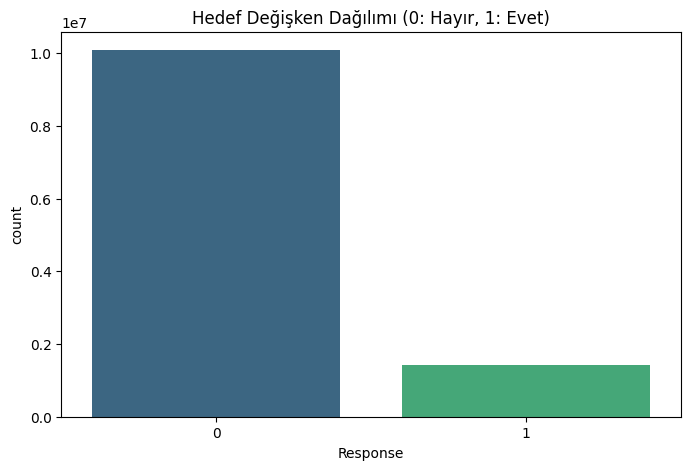

Response
0    10089739
1     1415059
Name: count, dtype: int64


In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train, x='Response', palette='viridis')
plt.title('Hedef Değişken Dağılımı (0: Hayır, 1: Evet)')
plt.show()

# Sayısal değerler
print(train['Response'].value_counts())

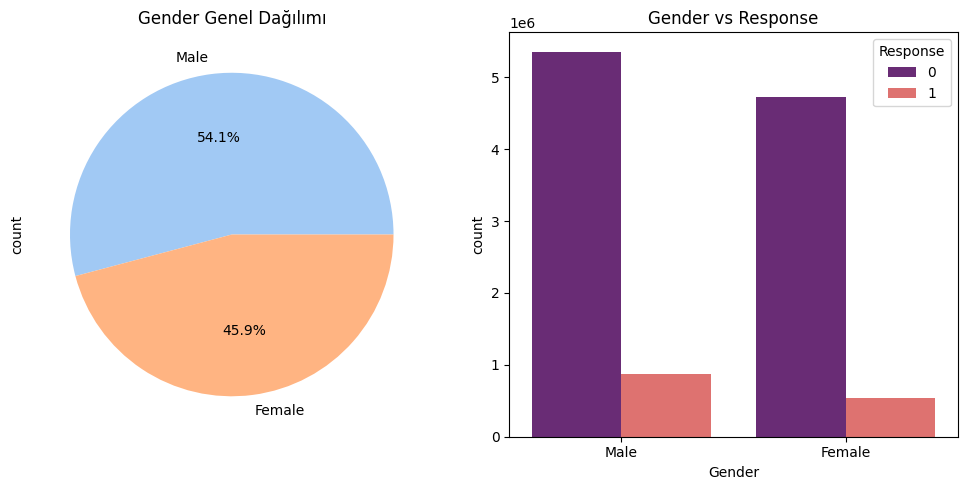

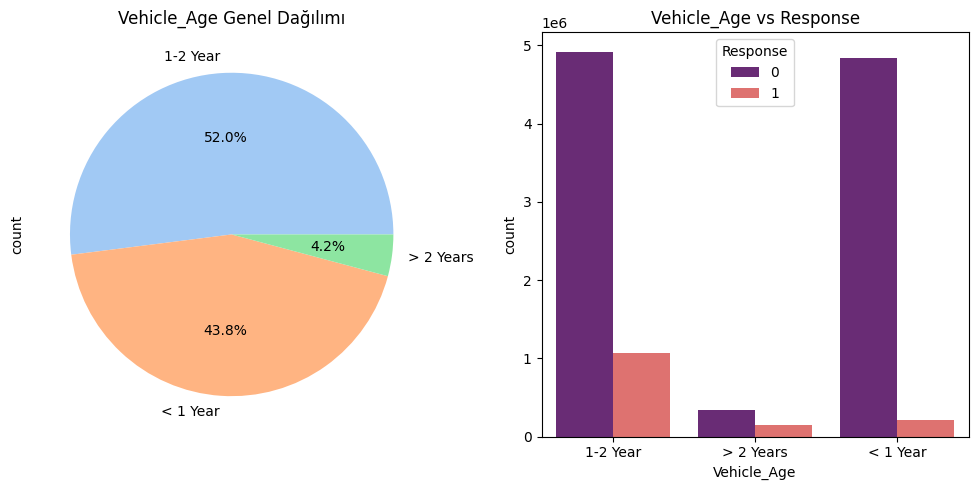

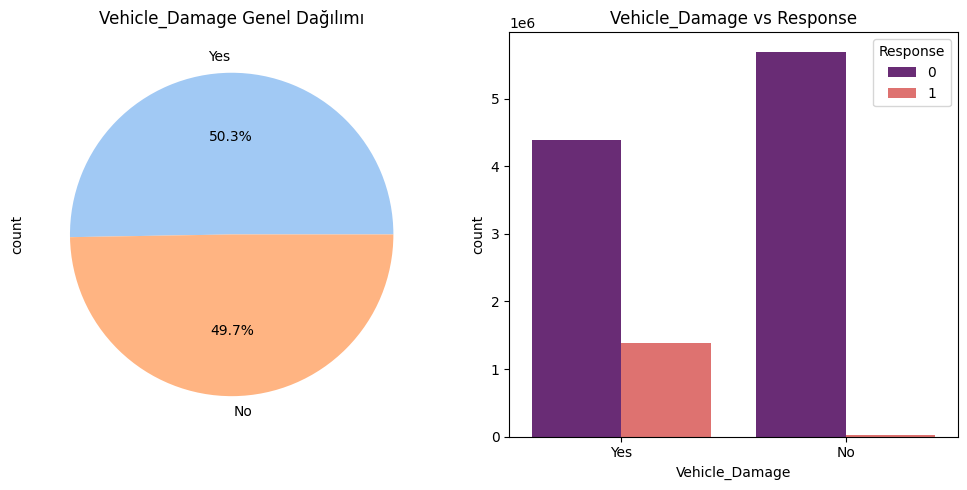

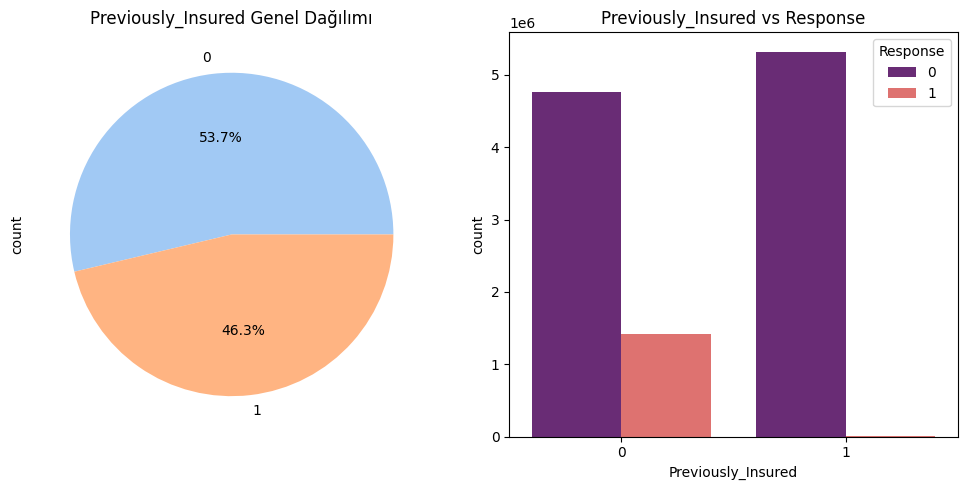

In [15]:
categorical_cols = ['Gender', 'Vehicle_Age', 'Vehicle_Damage', 'Previously_Insured']

for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    
    # Sol Grafik: Genel Dağılım
    plt.subplot(1, 2, 1)
    train[col].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
    plt.title(f'{col} Genel Dağılımı')
    
    # Sağ Grafik: Response ile İlişkisi
    plt.subplot(1, 2, 2)
    sns.countplot(data=train, x=col, hue='Response', palette='magma')
    plt.title(f'{col} vs Response')
    
    plt.tight_layout()
    plt.show()

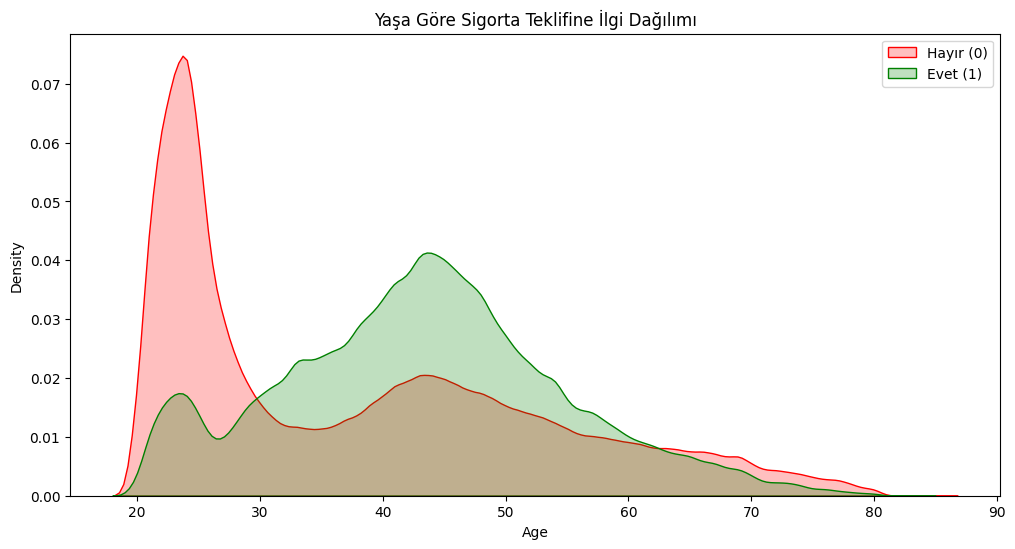

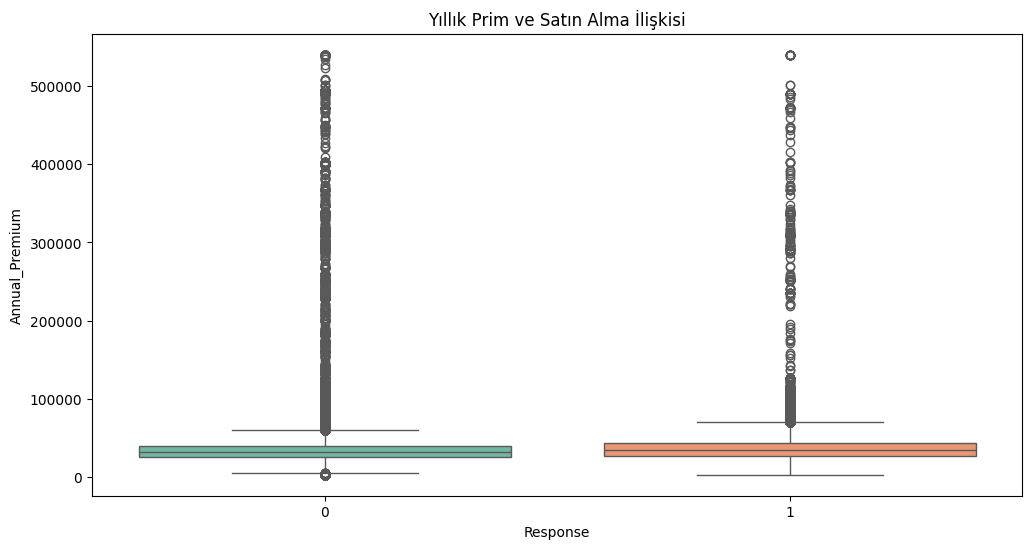

In [16]:
# Yaş Dağılımı ve Response İlişkisi
plt.figure(figsize=(12, 6))
sns.kdeplot(data=train[train['Response'] == 0], x='Age', fill=True, label='Hayır (0)', color='red')
sns.kdeplot(data=train[train['Response'] == 1], x='Age', fill=True, label='Evet (1)', color='green')
plt.title('Yaşa Göre Sigorta Teklifine İlgi Dağılımı')
plt.legend()
plt.show()

# Yıllık Prim Dağılımı (Uç değerler için logaritmik bakış gerekebilir)
plt.figure(figsize=(12, 6))
sns.boxplot(data=train, x='Response', y='Annual_Premium', palette='Set2')
plt.title('Yıllık Prim ve Satın Alma İlişkisi')
plt.show()

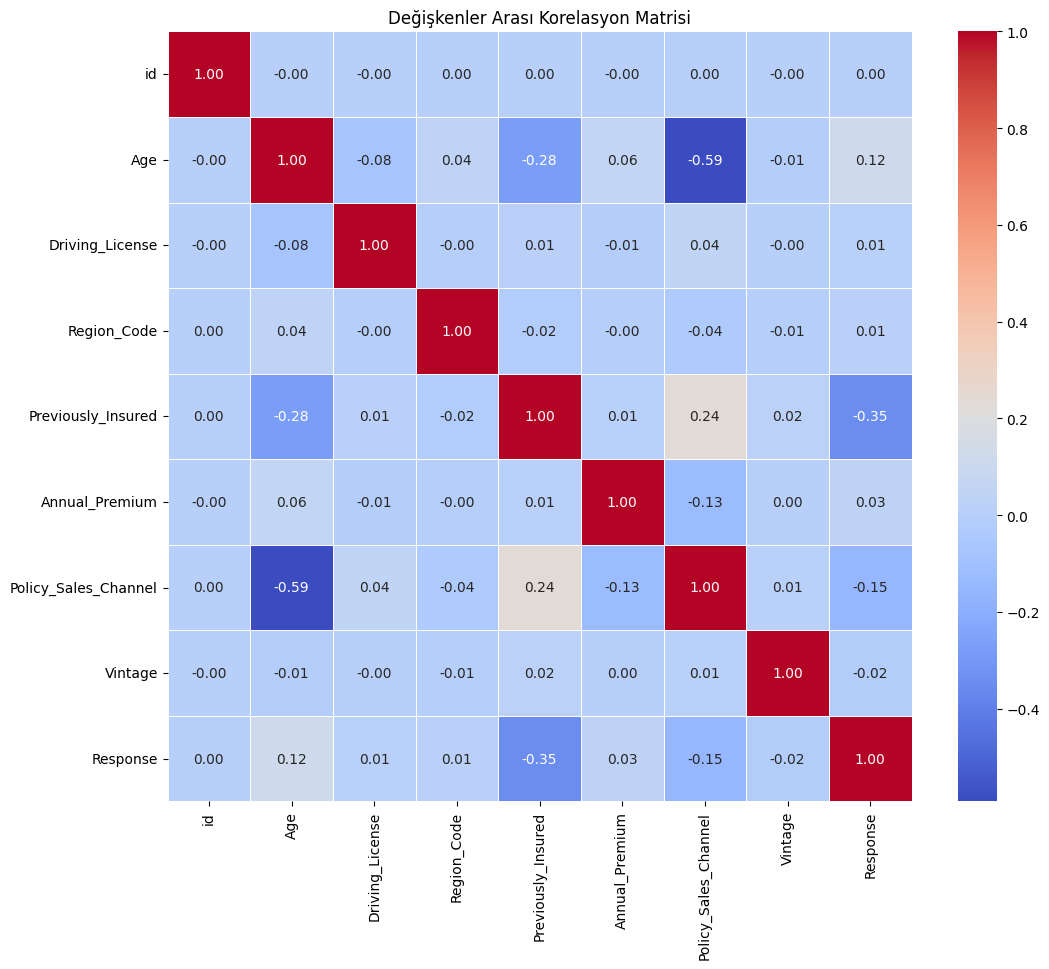

In [17]:
# Sadece sayısal sütunları seçelim
numeric_train = train.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_train.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Değişkenler Arası Korelasyon Matrisi')
plt.show()

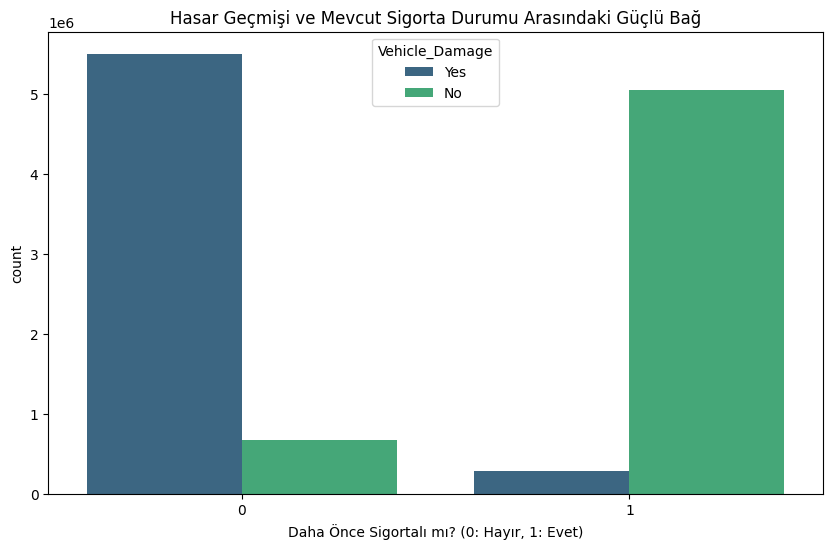

Vehicle_Damage            No       Yes
Previously_Insured                    
0                   0.109097  0.890903
1                   0.947598  0.052402


In [18]:
# Previously_Insured vs Vehicle_Damage Çapraz Tablosu
plt.figure(figsize=(10, 6))
sns.countplot(data=train, x='Previously_Insured', hue='Vehicle_Damage', palette='viridis')
plt.title('Hasar Geçmişi ve Mevcut Sigorta Durumu Arasındaki Güçlü Bağ')
plt.xlabel('Daha Önce Sigortalı mı? (0: Hayır, 1: Evet)')
plt.show()

# Oranları görmek için:
print(pd.crosstab(train['Previously_Insured'], train['Vehicle_Damage'], normalize='index'))

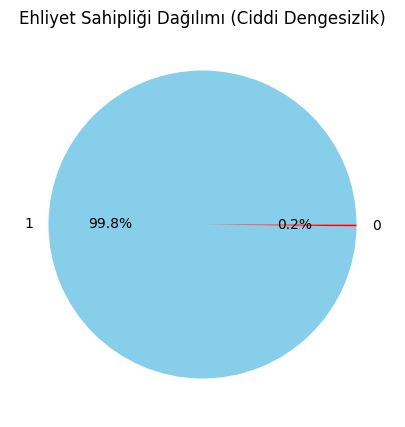

Driving_License
1    11482041
0       22757
Name: count, dtype: int64


In [19]:
# Ehliyet Dağılımı
plt.figure(figsize=(7, 5))
train['Driving_License'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'red'])
plt.title('Ehliyet Sahipliği Dağılımı (Ciddi Dengesizlik)')
plt.ylabel('')
plt.show()

# Value counts değerleri
print(train['Driving_License'].value_counts())

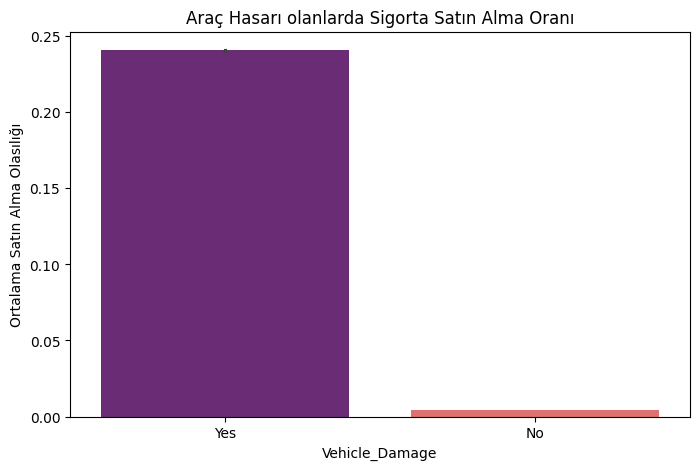

In [20]:
# Değişkenlerin Response üzerindeki etkisi (Örnek: Vehicle_Damage)
plt.figure(figsize=(8, 5))
sns.barplot(data=train, x='Vehicle_Damage', y='Response', palette='magma')
plt.title('Araç Hasarı olanlarda Sigorta Satın Alma Oranı')
plt.ylabel('Ortalama Satın Alma Olasılığı')
plt.show()

# Feature Engineering

In [21]:
def cleaned_data(df):
    # Eksik değer içeren satırları düşür (hata veren satırı temizle)
    df.dropna(inplace=True)

    # 1. Gereksiz sütunları bir kerede düşür (errors='ignore' id yoksa hata vermez)
    df = df.drop(columns=['id'], errors='ignore')

    # 2. Vektörize Mapping (Sözlük kullanarak doğrudan sütun bazlı dönüşüm)
    df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0}).astype('int8')
    df['Vehicle_Damage'] = df['Vehicle_Damage'].map({'Yes': 1, 'No': 0}).astype('int8')
    df['Vehicle_Age'] = df['Vehicle_Age'].map({'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2}).astype('int8')

    # 3. Feature Engineering

    # Yaşı anlamlı kategorik dilimlere bölüyoruz
    df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 45, 65, 100], labels=[0, 1, 2, 3]).astype('int8')
    # Risk Skoru: Hasar geçmişi var (1) + Sigortasız (1) = Max 2
    df['Risk_Score'] = (df['Vehicle_Damage'] + (1 - df['Previously_Insured'])).astype('int8')

    # 0: Sigortalı & Hasarsız (En düşük ihtimal)
    # 1: Sigortalı & Hasarlı
    # 2: Sigortasız & Hasarsız
    # 3: Sigortasız & Hasarlı (En yüksek ihtimal)
    df['Insured_Damage_Score'] = (df['Previously_Insured'] == 0).astype('int8') + (df['Vehicle_Damage'] == 1).astype('int8') * 2

    region_counts = df['Region_Code'].value_counts().to_dict()
    df['Region_Density'] = df['Region_Code'].map(region_counts)

    # 4. Outlier Capping (Baskılama)
    # Veriyi doğrudan üst sınırla kırpıyoruz
    upper_limit = df['Annual_Premium'].quantile(0.99)
    df['Annual_Premium'] = df['Annual_Premium'].clip(upper=upper_limit).astype('float32')


    # 5. Toplu Tip Dönüştürme (Hafıza yönetimi için)
    df = df.astype({
        'Age': 'int8',
        'Driving_License': 'int8',
        'Region_Code': 'int16',
        'Previously_Insured': 'int8',
        'Policy_Sales_Channel': 'int16',
        'Vintage': 'int16'
    })

    # Response varsa (Train seti ise) onu da küçült
    if 'Response' in df.columns:
        df['Response'] = df['Response'].astype('int8')

    return df

In [22]:
train_df=cleaned_data(train)

In [23]:
test_df=cleaned_data(test)

# model eğitimi

In [24]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

# Veriyi hazırlama
x = train_df.drop('Response', axis=1)
y = train_df['Response']

# Kategorik sütunları LightGBM'e tanıtmak performansı artırır
cat_features = ['Gender', 'Driving_License', 'Region_Code', 'Previously_Insured',
                'Vehicle_Age', 'Vehicle_Damage', 'Policy_Sales_Channel',
                'Age_Group', 'Risk_Score', 'Insured_Damage_Score']

In [25]:
# 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Skorları ve tahminleri tutmak için listeler
fold_scores = []
test_preds = np.zeros(len(test_df)) # Test seti tahminleri için

# Parametreler (M4 işlemci için optimize edilmiş)
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'n_jobs': -1, # Tüm M4 çekirdeklerini kullan
    'device': 'cpu', # MacOS'ta çoğu zaman CPU (M4) daha stabildir
    'random_state': 42,
    'verbose': -1
}

# Veriyi 5 parçaya bölen mekanizma burada:
for fold, (train_idx, val_idx) in enumerate(skf.split(x, y)):

    # İŞTE BURADA: Her döngüde verinin 4/5'i eğitim (x_train),
    # 1/5'i ise kontrol (X_val) için ayrılıyor.
    x_train, x_val = x.iloc[train_idx], x.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # LightGBM veri formatına dönüştürme
    dtrain = lgb.Dataset(x_train, label=y_train, categorical_feature=cat_features)
    dval = lgb.Dataset(x_val, label=y_val, categorical_feature=cat_features, reference=dtrain)

    # Model Eğitimi
    model = lgb.train(
        lgb_params,
        dtrain,
        num_boost_round=1000, # Deneme için düşük tutabilirsin, finalde artırılır
        valid_sets=[dtrain, dval],
        valid_names=['train', 'valid'],
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)]
    )

    # Validasyon tahmini ve skor hesaplama
    val_preds = model.predict(x_val)
    auc = roc_auc_score(y_val, val_preds)
    fold_scores.append(auc)

    print(f"Fold {fold + 1} AUC Skoru: {auc:.5f}")

    # Test seti için tahminleri biriktir (Average Blending)
    test_preds += model.predict(test_df.drop('id', axis=1, errors='ignore')) / skf.n_splits

print(f"\nOrtalama CV AUC Skoru: {np.mean(fold_scores):.5f}")

Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.873266	valid's auc: 0.872929
[200]	train's auc: 0.877005	valid's auc: 0.876519
[300]	train's auc: 0.878521	valid's auc: 0.877868
Early stopping, best iteration is:
[315]	train's auc: 0.878657	valid's auc: 0.877984
Fold 1 AUC Skoru: 0.87798
Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.873432	valid's auc: 0.873017
[200]	train's auc: 0.876953	valid's auc: 0.876406
[300]	train's auc: 0.878366	valid's auc: 0.877633
[400]	train's auc: 0.878886	valid's auc: 0.87798
Early stopping, best iteration is:
[366]	train's auc: 0.878931	valid's auc: 0.878085
Fold 2 AUC Skoru: 0.87809
Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.87339	valid's auc: 0.873214
[200]	train's auc: 0.877004	valid's auc: 0.876756
[300]	train's auc: 0.878476	valid's auc: 0.878089
[400]	train's auc: 0.87913	valid's auc: 0.878556
Early stopping, best iteration is:
[380]	train's

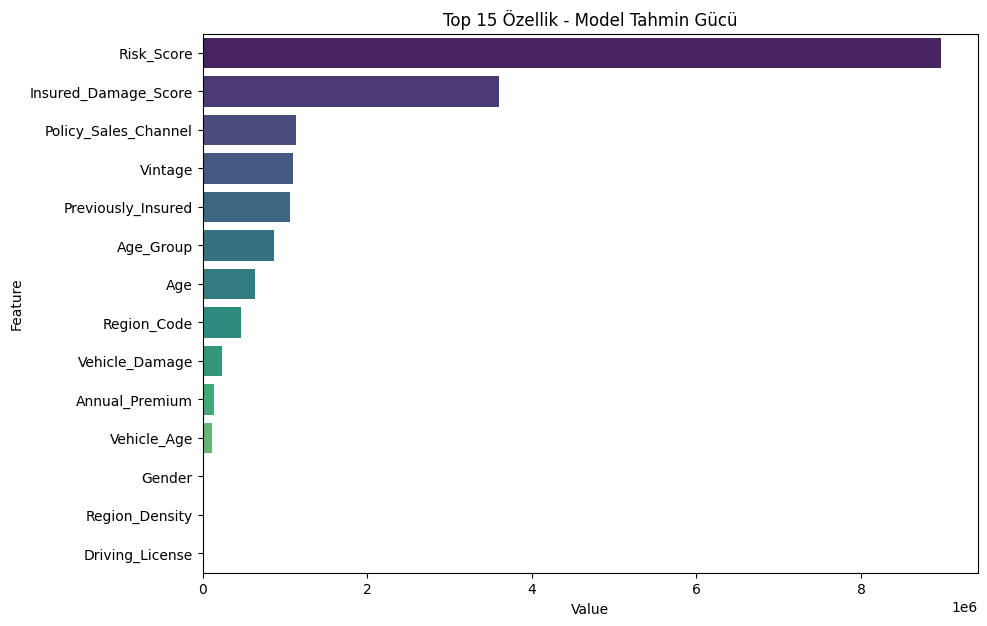

In [26]:
import pandas as pd
import seaborn as sns

# Önem skorlarını al ve sırala
feature_imp = pd.DataFrame({'Value': model.feature_importance(importance_type='gain'),
                           'Feature': x.columns}).sort_values(by="Value", ascending=False)

# Seaborn ile çizdir
plt.figure(figsize=(10, 7))
sns.barplot(x="Value", y="Feature", data=feature_imp.head(15), palette='viridis')
plt.title('Top 15 Özellik - Model Tahmin Gücü')
plt.show()

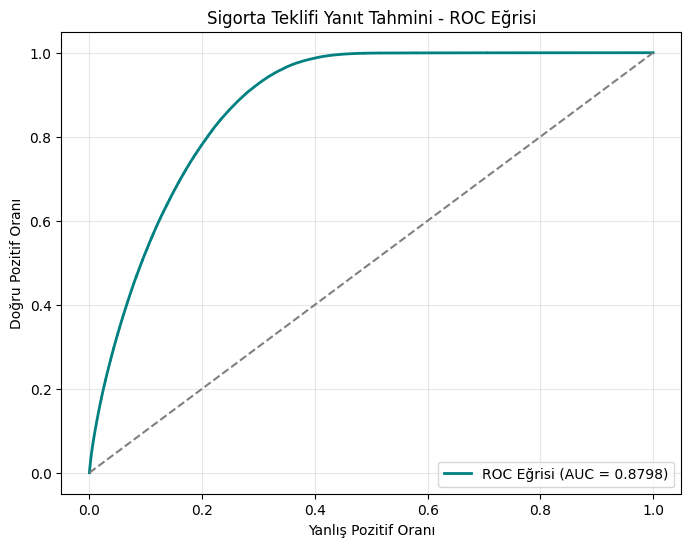

In [27]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Son fold'daki val_preds ve y_val değerlerini kullanıyoruz
fpr, tpr, thresholds = roc_curve(y_val, val_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='teal', lw=2, label=f'ROC Eğrisi (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('Sigorta Teklifi Yanıt Tahmini - ROC Eğrisi')
plt.xlabel('Yanlış Pozitif Oranı')
plt.ylabel('Doğru Pozitif Oranı')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Olasılıkları sınıfa çevir (0.5 eşik değeri)
y_pred_class = [1 if x > 0.5 else 0 for x in val_preds]
cm = confusion_matrix(y_val, y_pred_class)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['İlgilenmiyor', 'İlgileniyor'])
disp.plot(cmap='YlGnBu', values_format='d')
plt.title('Sigorta Teklifi - Karmaşıklık Matrisi')
plt.show()

In [ ]:
# 1. Test dosyasını sadece 'id' sütununu alacak şekilde tekrar oku
test_ids = pd.read_csv('test.csv', usecols=['id'])

# 2. Tahminlerinle bu ID'leri birleştir
submission = pd.DataFrame({
    'id': test_ids['id'],
    'Response': test_preds
})

# 3. Dosyayı kaydet
submission.to_csv('submission_lgbm_v1.csv', index=False)

print("İşlem tamam! 'id' sütunu başarıyla eklendi ve submission dosyası hazırlandı.")

In [ ]:
model.save_model('lgbm_model.txt')

In [ ]:
submission

## 🏁 Sonuç ve Değerlendirme

Bu projede, bir veri seti üzerinde **LightGBM** ve **Stratified K-Fold** (5-Fold) yöntemlerini kullanarak yüksek performanslı bir sınıflandırma modeli geliştirilmiştir.

### 📈 Elde Edilen Başarılar:
*   **Model Performansı:** Yerel doğrulamada (CV) **0.87854 AUC** skoruna ulaşılmıştır.
*   **Veri Mühendisliği:** Müşteri risk skorları ve yaş gruplandırmaları gibi yeni özellikler (feature engineering) eklenerek modelin tahmin gücü artırılmıştır.